# 04 — Treasury yields vs the factor prediction

Three charts, one per tenor, each overlaying the actual yield on the
credibility factor and its AR(1) forecast. Why these three tenors tell
different stories:

- **2y** = almost pure **policy expectations**. If the market believes
  hikes are coming (credibility rebuilding), the 2y rises WITH the
  factor.
- **5y** = the **belly**, where medium-term inflation expectations live.
- **10y** = **growth + term premium**. A credibility UNWIND shows up as
  the long end selling off (yields UP while the factor goes DOWN) —
  exactly the "30y yields drove 31% of the retracement" pattern.

So the healthy sign-check: 2y roughly WITH the factor, 10y roughly
AGAINST it during credibility repricings. Where that flips, something
else (growth scare, supply) is driving the curve.

Run notebooks 01→02 first (this reads their caches). 03 is optional —
if its fitted forecast exists, it is overlaid too.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg
import factor_lib as fl

# ------------------- settings -------------------
PLOT_START = None      # e.g. "2026-04-01"; None = last ~4 months
SHOW_FITTED = True     # overlay notebook 03's fitted forecast if available
# -------------------------------------------------

factor = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]
fc_eq = pd.read_csv("forecast_equal.csv", parse_dates=["date"])
events = pd.read_csv("events.csv", parse_dates=["date"])

fc_fit = None
if SHOW_FITTED and os.path.exists("forecast_fitted.csv"):
    fc_fit = pd.read_csv("forecast_fitted.csv", parse_dates=["date"])

plot_start = (pd.Timestamp(PLOT_START) if PLOT_START
              else factor.index[-1] - pd.Timedelta(days=120))

if bbg.MOCK_MODE:
    print("MOCK MODE - synthetic yields; shapes are illustrative only.")

### Pull the three yields

One batched request. `PX_LAST` on a `USGGxYR Index` ticker IS the yield
in percent.

In [2]:
YIELDS = {"USGG2YR Index": "2y yield",
          "USGG5YR Index": "5y yield",
          "USGG10YR Index": "10y yield"}

yields = bbg.bdh(list(YIELDS), "PX_LAST",
                 pd.Timestamp(2025, 1, 1).date()).ffill().dropna()
print(yields.tail(3).round(3))

  got USGG2YR Index: 397 rows
  got USGG5YR Index: 397 rows
  got USGG10YR Index: 397 rows
            USGG2YR Index  USGG5YR Index  USGG10YR Index
2026-07-09          4.176          4.283           4.551
2026-07-10          4.208          4.305           4.561
2026-07-13          4.214          4.314           4.569


### How closely does each tenor track the factor?

Correlation of DAILY CHANGES (levels would mislead — see notebook 02 of
the monitor for why). Expected on real data: 2y positive (policy leg),
10y negative-ish (credibility premium leg).

In [3]:
factor_moves = factor.diff()
for ticker, label in YIELDS.items():
    corr = yields[ticker].diff().corr(factor_moves)
    print(f"{label:<10} daily-change corr with factor: {corr:+.2f}")

2y yield   daily-change corr with factor: +0.03
5y yield   daily-change corr with factor: -0.10
10y yield  daily-change corr with factor: -0.21


### The three overlay charts

Left axis (color) = the yield in %. Right axis (dark blue) = the factor
in z-units with its forecast fan. Dotted verticals = FOMC (red) and
CPI/NFP (grey) days, including upcoming ones inside the forecast window.

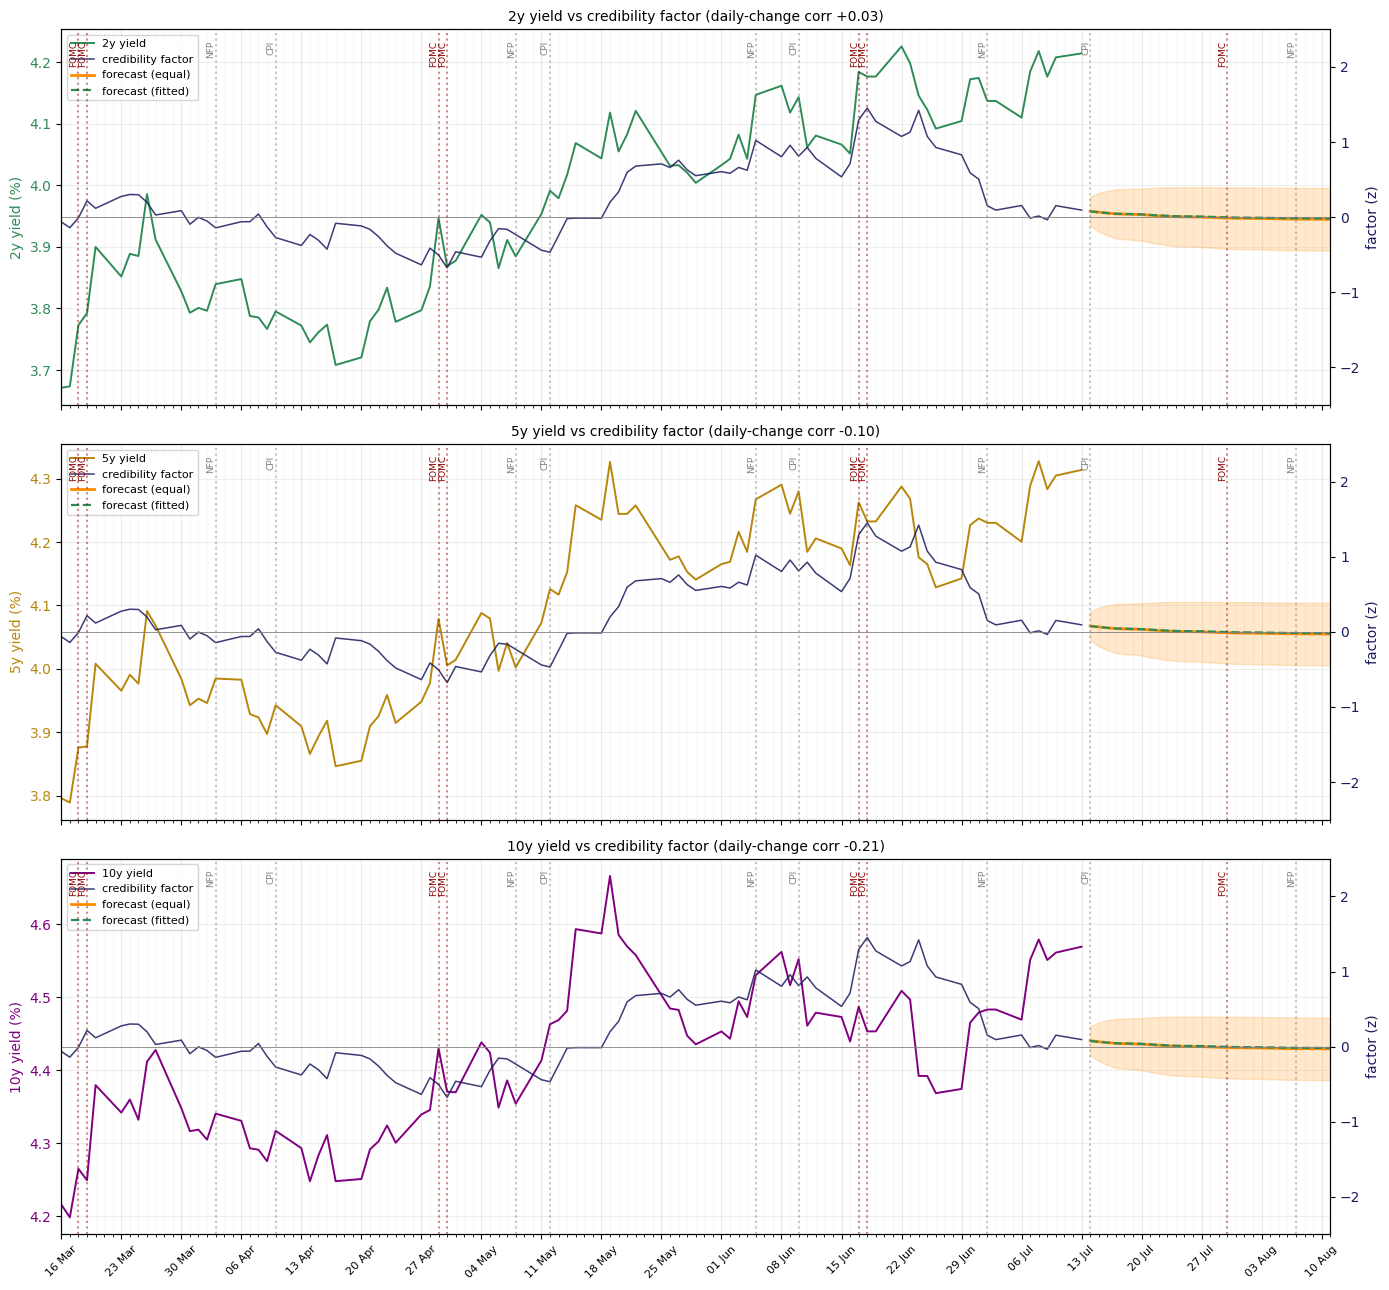

In [4]:
def annotate_axis(ax, xmin, xmax):
    lo, hi = ax.get_ylim()
    for _, ev in events.iterrows():
        if xmin <= ev["date"] <= xmax:
            color = "darkred" if ev["label"] == "FOMC" else "grey"
            ax.axvline(ev["date"], color=color, linestyle=":", alpha=0.45)
            ax.text(ev["date"], hi - (hi - lo) * 0.03, ev["label"],
                    color=color, fontsize=6.5, rotation=90,
                    ha="right", va="top", clip_on=True)


hist = factor[factor.index >= plot_start]
fdates = fc_eq["date"]
path, spread = fc_eq["path"].values, fc_eq["spread"].values
xmin, xmax = hist.index[0], fdates.iloc[-1]

colors = {"USGG2YR Index": "seagreen",
          "USGG5YR Index": "darkgoldenrod",
          "USGG10YR Index": "purple"}

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

for ax, (ticker, label) in zip(axes, YIELDS.items()):
    y_win = yields.loc[yields.index >= plot_start, ticker]

    # left axis: the yield itself
    ax.plot(y_win.index, y_win.values, color=colors[ticker],
            linewidth=1.4, label=label)
    ax.set_ylabel(f"{label} (%)", color=colors[ticker])
    ax.tick_params(axis="y", labelcolor=colors[ticker])

    # right axis: the factor + prediction
    ax2 = ax.twinx()
    ax2.plot(hist.index, hist.values, color="#1a1a5e", linewidth=1.1,
             alpha=0.85, label="credibility factor")
    ax2.plot(fdates, path, color="darkorange", linewidth=2,
             label="forecast (equal)")
    ax2.fill_between(fdates, path - spread, path + spread,
                     color="darkorange", alpha=0.20)
    if fc_fit is not None:
        ax2.plot(fc_fit["date"], fc_fit["path"], color="seagreen",
                 linewidth=1.6, linestyle="--", label="forecast (fitted)")
    ax2.axhline(0, color="grey", linewidth=0.6)
    ax2.set_ylim(-2.5, 2.5)
    ax2.set_ylabel("factor (z)", color="#1a1a5e")
    ax2.tick_params(axis="y", labelcolor="#1a1a5e")

    ax.set_xlim(xmin, xmax)
    annotate_axis(ax2, xmin, xmax)
    fl.format_time_axis(ax, freq="week")

    # one merged legend per panel
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)

    corr = yields[ticker].diff().corr(factor_moves)
    ax.set_title(f"{label} vs credibility factor "
                 f"(daily-change corr {corr:+.2f})", fontsize=10)

plt.tight_layout()
plt.savefig("yields_vs_prediction.png", dpi=120)
plt.show()

### Reading these panels

- The forecast fan is for the FACTOR, not the yields — the point of the
  overlay is to see whether each tenor is confirming or fighting the
  predicted path. If the factor is forecast to mean-revert upward
  (credibility rebuilding) you would EXPECT: 2y drifting up with it,
  10y stable-to-lower as the inflation premium comes back out.
- A day where the 10y jumps while the factor holds = term-premium /
  supply noise, not a credibility event. The factor filters that; the
  overlay makes it visible.
- The FOMC line inside the fan window is the event most likely to snap
  both the yields AND the factor off their paths.